In [ ]:
import pandas as pd
from google.colab import files
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_curve, roc_auc_score, precision_recall_curve)
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

In [ ]:
# Uploaded File

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

Saving einkommen_with_headers.csv to einkommen_with_headers (1).csv


In [ ]:
# Preprocess Data

df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
df.replace(["?", ""], np.nan, inplace=True)

<ipython-input-5-9b6e2203a781>:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [ ]:
# Define Variable

target_column = 'Income'

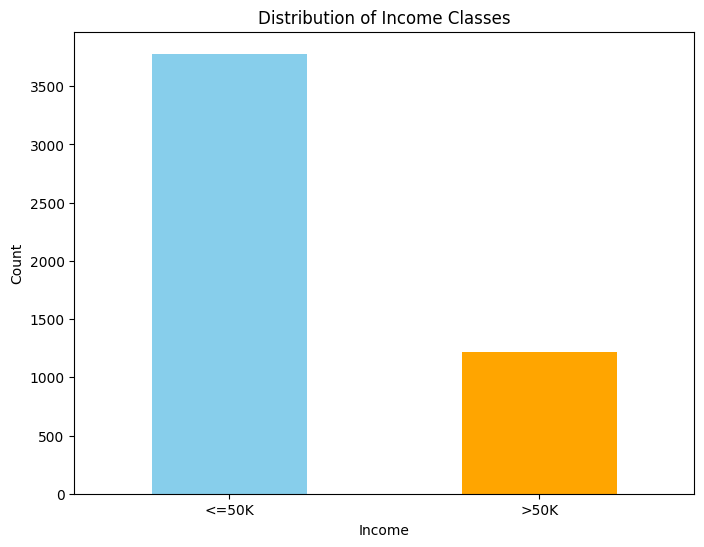

In [ ]:
# Plot histogram of the target variable 'Income'

plt.figure(figsize=(8, 6))
df[target_column].value_counts().plot(kind='bar', color=['skyblue', 'orange'])
plt.title('Distribution of Income Classes')
plt.xlabel('Income')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Replace NaN values excluding the target column

categorical_columns = df.select_dtypes(include=['object']).columns

for column in categorical_columns:
    if column != target_column:
        if not df[column].isna().all():
            most_frequent = df[column].mode()[0]
            df[column].fillna(most_frequent, inplace=True)

<ipython-input-8-0b0f2075bb77>:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(most_frequent, inplace=True)


In [ ]:
# Encode nominal and ordinal features

nominal_features = ['Employment type', 'Marital status', 'Employment area', 'Partnership', 'Ethnicity', 'Gender', 'Country of birth']
ordinal_features = ['Level of education', 'Schooling/Training Period']

In [ ]:
# Ordinal Encoding

education_ranking = {
    'Preschool': 1,
    '1st-4th': 2,
    '5th-6th': 3,
    '7th-8th': 4,
    '9th': 5,
    '10th': 6,
    '11th': 7,
    '12th': 8,
    'HS-grad': 9,
    'Some-college': 10,
    'Assoc-acdm': 11,
    'Assoc-voc': 12,
    'Bachelors': 13,
    'Masters': 14,
    'Prof-school': 15,
    'Doctorate': 16
}

if 'Level of education' in df.columns:
    df['Level of education'] = df['Level of education'].map(education_ranking)

if 'Schooling/Training Period' in df.columns:
    schooling_ranking = {str(i): i for i in range(1, 21)}  # Assuming years 1 to 20
    df['Schooling/Training Period'] = df['Schooling/Training Period'].map(schooling_ranking)

In [ ]:
# One-hot encoding

df = pd.get_dummies(df, columns=nominal_features, drop_first=True)
df = df.applymap(lambda x: 1 if x is True else (0 if x is False else x))

<ipython-input-11-500e29897d87>:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: 1 if x is True else (0 if x is False else x))


In [ ]:
# Normalize using MinMaxScaler

numerical_columns = df.select_dtypes(include=[np.number]).columns
if target_column in numerical_columns:
    numerical_columns = numerical_columns.drop(target_column)
scaler = MinMaxScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

In [ ]:
# Separate the labeled data

labeled_data = df.iloc[1:5001]
unlabeled_data = df.iloc[5001:30001]

# Split the labeled data into features (X) and target (y)

X = labeled_data.drop(columns=[target_column])
y = labeled_data[target_column]

In [ ]:
# Encode the target variable as binary and Apply SMOTE to balance
y = y.apply(lambda x: 1 if x == '>50K' else 0)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [ ]:
# Split the resampled data into an train-test split

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2)

In [ ]:
# Hyperparameter tuning with Grid Search for Logistic Regression and train the model

param_grid_logistic = {
    'C': [0.1, 1, 5, 10, 20, 50, 100, 200, 500, 1000],
    'solver': ['liblinear']
}

grid_search_logistic = GridSearchCV(estimator=LogisticRegression(), param_grid=param_grid_logistic, cv=5, n_jobs=-1, verbose=2, scoring='accuracy')
grid_search_logistic.fit(X_train, y_train)

print("Best Hyperparameters for Logistic Regression:", grid_search_logistic.best_params_)

best_model_logistic = grid_search_logistic.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Hyperparameters for Logistic Regression: {'C': 50, 'solver': 'liblinear'}


In [ ]:
# Evaluate Logistic Regression model on the test data

y_prob_logistic = best_model_logistic.predict_proba(X_test)[:, 1]
y_pred_logistic = (y_prob_logistic >= 0.4).astype(int)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
print(f"Logistic Regression Accuracy: {accuracy_logistic:.2f}")

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logistic))

print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

Logistic Regression Accuracy: 0.83
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.74      0.82       775
           1       0.77      0.92      0.84       737

    accuracy                           0.83      1512
   macro avg       0.84      0.83      0.83      1512
weighted avg       0.84      0.83      0.83      1512

Logistic Regression Confusion Matrix:
[[577 198]
 [ 56 681]]


In [ ]:
# Hyperparameter tuning with Grid Search for Random Forest and train the model
param_grid_random_forest = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

grid_search_random_forest = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid_random_forest, cv=5, n_jobs=-1, verbose=2, scoring='accuracy')
grid_search_random_forest.fit(X_train, y_train)

print("Best Hyperparameters for Random Forest:", grid_search_random_forest.best_params_)

best_model_random_forest = grid_search_random_forest.best_estimator_

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Hyperparameters for Random Forest: {'max_depth': None, 'min_samples_split': 2}


In [ ]:
# Evaluate the Random Forest model on the test data

y_prob_random_forest = best_model_random_forest.predict_proba(X_test)[:, 1]
y_pred_random_forest = (y_prob_random_forest >= 0.5).astype(int)  # Using default threshold of 0.5

accuracy_random_forest = accuracy_score(y_test, y_pred_random_forest)
print(f"Random Forest Accuracy: {accuracy_random_forest:.2f}")

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_random_forest))

print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_random_forest))


Random Forest Accuracy: 0.89
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.86      0.89       775
           1       0.86      0.92      0.89       737

    accuracy                           0.89      1512
   macro avg       0.89      0.89      0.89      1512
weighted avg       0.89      0.89      0.89      1512

Random Forest Confusion Matrix:
[[667 108]
 [ 57 680]]


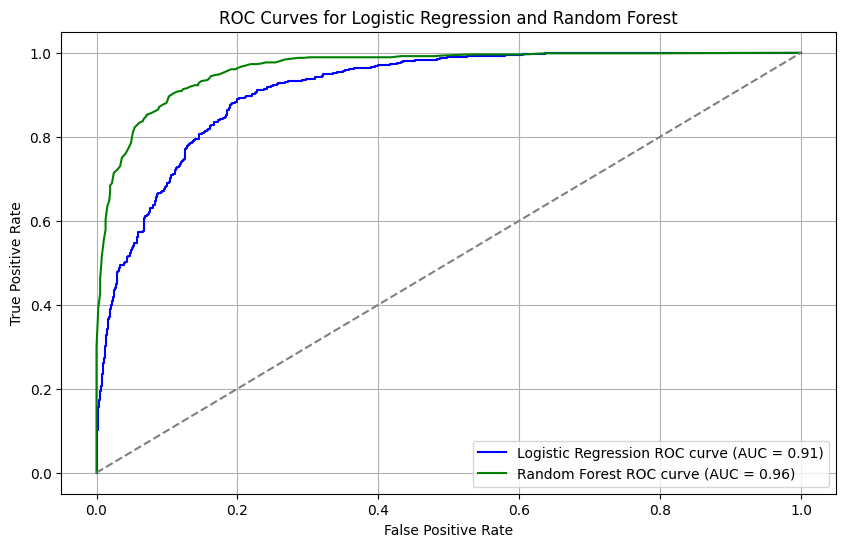

In [ ]:
# ROC and AUC for both models

fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_prob_logistic)
roc_auc_logistic = roc_auc_score(y_test, y_prob_logistic)

fpr_random_forest, tpr_random_forest, _ = roc_curve(y_test, y_prob_random_forest)
roc_auc_random_forest = roc_auc_score(y_test, y_prob_random_forest)

plt.figure(figsize=(10, 6))
plt.plot(fpr_logistic, tpr_logistic, color='blue', label=f'Logistic Regression ROC curve (AUC = {roc_auc_logistic:.2f})')
plt.plot(fpr_random_forest, tpr_random_forest, color='green', label=f'Random Forest ROC curve (AUC = {roc_auc_random_forest:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Logistic Regression and Random Forest')
plt.legend(loc='lower right')
plt.grid()
plt.show()

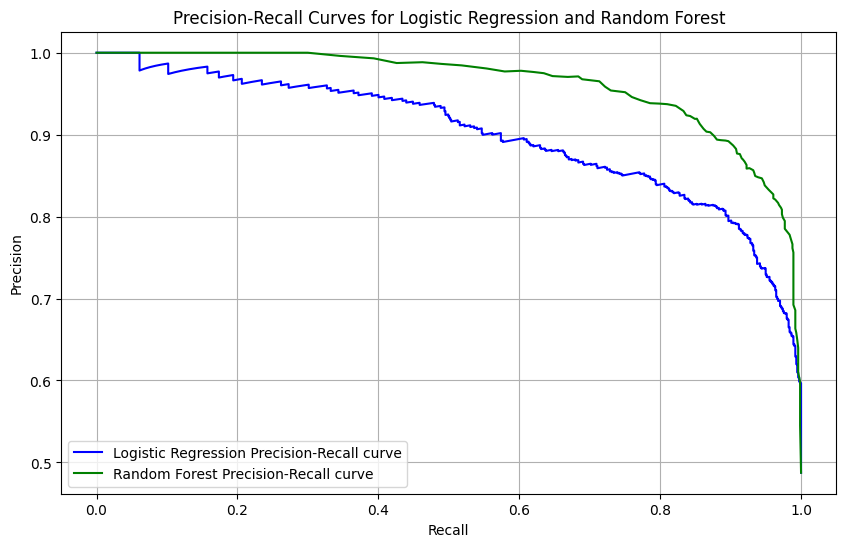

In [ ]:
# Precision-Recall Curve for both models

precision_logistic, recall_logistic, _ = precision_recall_curve(y_test, y_prob_logistic)
precision_random_forest, recall_random_forest, _ = precision_recall_curve(y_test, y_prob_random_forest)

plt.figure(figsize=(10, 6))
plt.plot(recall_logistic, precision_logistic, color='blue', label='Logistic Regression Precision-Recall curve')
plt.plot(recall_random_forest, precision_random_forest, color='green', label='Random Forest Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Logistic Regression and Random Forest')
plt.legend(loc='lower left')
plt.grid()
plt.show()

In [ ]:
# Save predictions
unlabeled_features = unlabeled_data.drop(columns=[target_column])
predictions_random_forest = best_model_random_forest.predict(unlabeled_features)
predictions_proba_random_forest = best_model_random_forest.predict_proba(unlabeled_features)[:, 1]

unlabeled_results = pd.DataFrame({
    'Predicted Income': predictions_random_forest,
    'Probability': predictions_proba_random_forest
})

unlabeled_results.to_csv('predictions_random_forest.csv', index=False)
print("Predictions saved to 'predictions_random_forest.csv'")

Predictions saved to 'predictions_random_forest.csv'
